<a href="https://colab.research.google.com/github/Li2angel/BatteryInsight/blob/main/notebooks/03_soh_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: State-of-Health (SOH) Prediction
**Research questions:**
1. Can SOH be estimated from **discharge-curve health indicators** rather than by directly measuring capacity?
2. Does the SOH model **generalise to an unseen battery cell**?

**Dataset:** NASA Li-Ion Aging Dataset, cells B0005/6/7/18. **Target:** `SOH = capacity / initial_capacity` (per cell).
This is per-cycle regression (~168 rows/cell). We evaluate in **two regimes** and show the model choice must match the regime.

## 1. Setup & data

In [1]:
!git clone --depth 1 https://github.com/XiuzeZhou/NASA.git nasa_repo 2>/dev/null
DATA_DIR='nasa_repo/dataset'

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, joblib
from scipy.io import loadmat
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

os.makedirs('figures',exist_ok=True); os.makedirs('models',exist_ok=True)

## 2. Per-cycle feature extraction
For each discharge cycle we compute interpretable **health indicators (HIs)** from the curve, crucially **not** capacity itself (that would be circular). The key HI is `vdrop_time`: the time for the discharge voltage to fall from 3.8 V to 3.4 V. As a cell ages this window shrinks, so it tracks degradation while being measurable from a *partial* discharge, realistic for a deployed BMS.

In [2]:
def per_cycle_features(path, name):
    cycles=loadmat(path)[name][0,0]['cycle'][0]; rows,dc=[],0
    for c in cycles:
        if c['type'][0]!='discharge': continue
        d=c['data'][0,0]; cap=float(d['Capacity'][0][0])
        V=d['Voltage_measured'][0]; T=d['Temperature_measured'][0]; t=d['Time'][0]; dc+=1
        def t_at(thr):
            i=np.where(V<=thr)[0]; return t[i[0]] if len(i) else np.nan
        rows.append(dict(battery=name, cycle=dc, capacity=cap,
                         mean_temp=float(np.mean(T)), max_temp=float(np.max(T)),
                         v_end=float(np.min(V)), vdrop_time=t_at(3.4)-t_at(3.8)))
    df=pd.DataFrame(rows); df['soh']=df['capacity']/df['capacity'].iloc[0]
    return df

In [3]:
bats=['B0005','B0006','B0007','B0018']
data=pd.concat([per_cycle_features(f'{DATA_DIR}/{b}.mat',b) for b in bats], ignore_index=True).dropna().reset_index(drop=True)
FEATURES=['cycle','vdrop_time','mean_temp','max_temp','v_end']   # capacity excluded on purpose

print('rows:', len(data), '| per cell:', data.battery.value_counts().to_dict())
data.head(3)

rows: 636 | per cell: {'B0005': 168, 'B0006': 168, 'B0007': 168, 'B0018': 132}


,battery,cycle,capacity,mean_temp,max_temp,v_end,vdrop_time,soh
0,B0005,1,1.856487,32.572328,38.982181,2.612467,2422.656,1.000000
1,B0005,2,1.846327,32.725235,39.033398,2.587209,2424.844,0.994527
2,B0005,3,1.835349,32.642862,38.818797,2.651917,2424.907,0.988614


## 3. Capacity-fade curves & feature relevance
SOH declines monotonically with cycling; cells degrade at different rates (B0006 fastest). The HIs correlate strongly with SOH.

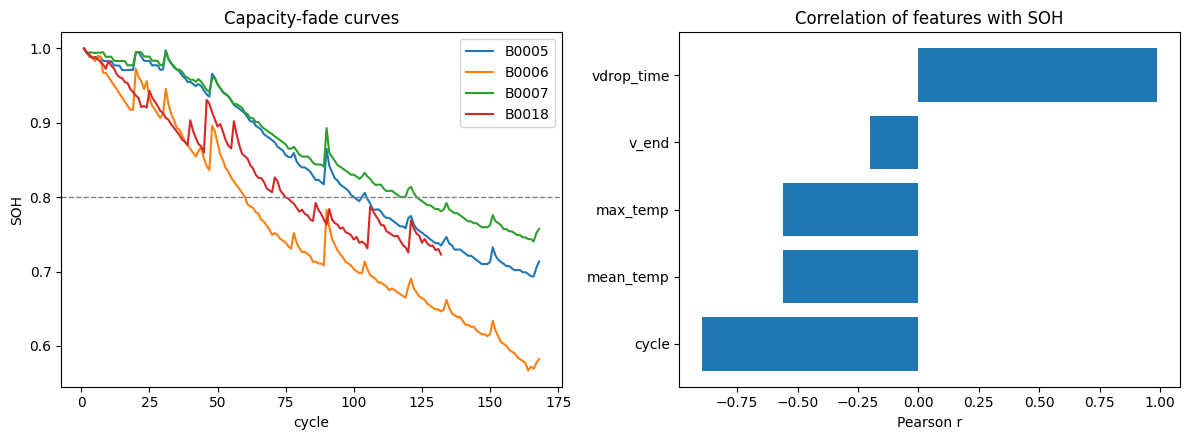

,soh
cycle,-0.894
mean_temp,-0.562
max_temp,-0.560
v_end,-0.200
vdrop_time,0.987


In [4]:
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
for b in bats:
    s=data[data.battery==b]; ax[0].plot(s.cycle, s.soh, label=b)
ax[0].axhline(0.8,ls='--',c='grey',lw=1); ax[0].set_xlabel('cycle'); ax[0].set_ylabel('SOH')
ax[0].set_title('Capacity-fade curves'); ax[0].legend()
corr=data[FEATURES+['soh']].corr()['soh'].drop('soh').sort_values()
ax[1].barh(corr.index, corr.values); ax[1].set_title('Correlation of features with SOH'); ax[1].set_xlabel('Pearson r')
plt.tight_layout(); plt.savefig('figures/m2_fade_and_corr.png',dpi=120); plt.show()
corr.round(3)

## 4. Two evaluation regimes
- **Regime A, within-battery forecasting:** train on a cell's early life, predict its *future* SOH (cycles below any seen value). This is **extrapolation**.
- **Regime B, cross-battery transfer:** train on three cells, predict an unseen fourth (leave-one-battery-out). The training cells already span the full SOH range, so this is **interpolation across cells**.

The right model differs between them, that is the core lesson of this module.

### Regime A: within-battery forecasting (extrapolation)
**Finding:** Tree models predict constants in their leaves and **cannot extrapolate** below the lowest SOH they saw; linear models can follow the fade trend.

In [14]:
b5=data[data.battery=='B0005'].reset_index(drop=True)
s=int(0.8*len(b5)); trA,teA=b5.iloc[:s],b5.iloc[s:]
def fit_eval(m):
    m.fit(trA[FEATURES],trA.soh); p=m.predict(teA[FEATURES])
    return np.sqrt(mean_squared_error(teA.soh,p)), r2_score(teA.soh,p), p
for name,m in [('XGBoost', xgb.XGBRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=0)),
               ('LinearReg', LinearRegression())]:
    rmse,r2,_=fit_eval(m); print(f'{name:10s} test RMSE={rmse:.4f}  R2={r2:.3f}')

XGBoost    test RMSE=0.0261  R2=-3.777
LinearReg  test RMSE=0.0039  R2=0.892


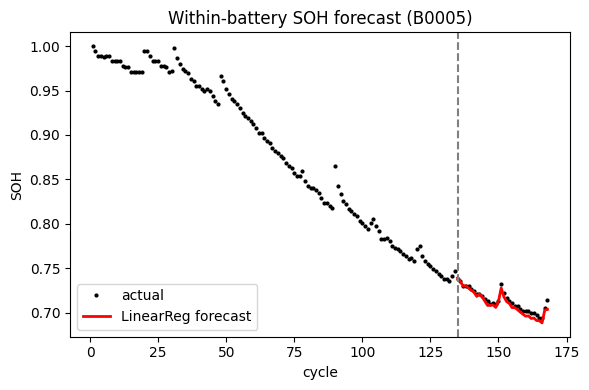

In [15]:
lin=LinearRegression(); _,_,pl=fit_eval(lin)

plt.figure(figsize=(6,4))
plt.plot(b5.cycle,b5.soh,'k.',label='actual',ms=4)
plt.plot(teA.cycle,pl,'r-',lw=2,label='LinearReg forecast')
plt.axvline(b5.cycle.iloc[s],ls='--',c='grey'); plt.xlabel('cycle'); plt.ylabel('SOH')
plt.title('Within-battery SOH forecast (B0005)'); plt.legend()
plt.tight_layout(); plt.savefig('figures/m2_within_forecast.png',dpi=120); plt.show()

### Regime B: cross-battery transfer (leave-one-battery-out)
The honest generalisation test: can a model trained on some cells estimate SOH on a cell it has never seen?

**Finding:** Tree models excel here because it is interpolation across the SOH range.

In [16]:
def evi(y,p):
  return np.sqrt(mean_squared_error(y,p)), mean_absolute_error(y,p), r2_score(y,p)

rows=[]

for tb in bats:
    tr=data[data.battery!=tb]; te=data[data.battery==tb]
    for name,m in [('RandomForest',RandomForestRegressor(n_estimators=300,max_depth=6,min_samples_leaf=3,n_jobs=-1,random_state=0)),
                   ('XGBoost',xgb.XGBRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,n_jobs=-1,random_state=0))]:
        m.fit(tr[FEATURES],tr.soh)
        rtr=r2_score(tr.soh,m.predict(tr[FEATURES])); rmse,mae,r2=evi(te.soh,m.predict(te[FEATURES]))
        rows.append({'held-out':tb,'model':name,'train_R2':round(rtr,3),'test_RMSE':round(rmse,4),'test_MAE':round(mae,4),'test_R2':round(r2,3)})


res=pd.DataFrame(rows)
print(res.to_string(index=False))
xgb_r2=res[res.model=='XGBoost'].test_R2
print(f'\nXGBoost cross-battery mean R2 = {xgb_r2.mean():.3f} +/- {xgb_r2.std():.3f}')

held-out        model  train_R2  test_RMSE  test_MAE  test_R2
   B0005 RandomForest     0.996     0.0260    0.0208    0.936
   B0005      XGBoost     0.998     0.0305    0.0243    0.911
   B0006 RandomForest     0.999     0.0581    0.0491    0.778
   B0006      XGBoost     1.000     0.0557    0.0469    0.796
   B0007 RandomForest     0.997     0.0267    0.0217    0.901
   B0007      XGBoost     0.999     0.0296    0.0203    0.879
   B0018 RandomForest     0.997     0.0311    0.0280    0.860
   B0018      XGBoost     0.999     0.0360    0.0318    0.812

XGBoost cross-battery mean R2 = 0.850 +/- 0.055


### Cross-battery diagnostic plot
Predicted vs actual SOH over cycles for the hardest held-out cell (B0006).

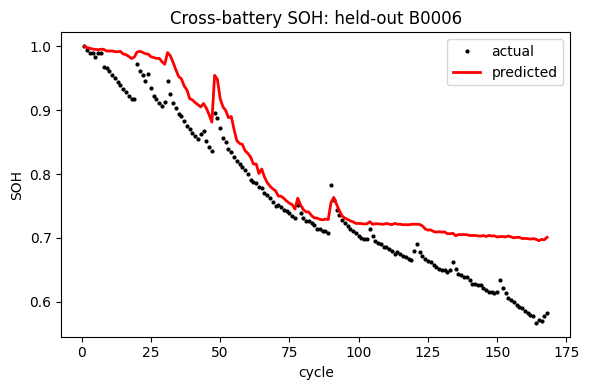

In [18]:
tb='B0006'; tr=data[data.battery!=tb]; te=data[data.battery==tb].sort_values('cycle')

best=xgb.XGBRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,n_jobs=-1,random_state=0).fit(tr[FEATURES],tr.soh)
pred=best.predict(te[FEATURES])

plt.figure(figsize=(6,4))
plt.plot(te.cycle,te.soh,'k.',label='actual',ms=4); plt.plot(te.cycle,pred,'r-',lw=2,label='predicted')
plt.xlabel('cycle'); plt.ylabel('SOH'); plt.title(f'Cross-battery SOH: held-out {tb}'); plt.legend()
plt.tight_layout(); plt.savefig('figures/m2_crossbattery_B0006.png',dpi=120); plt.show()

## 5. Discussion (drop into README / report)
**HI quality.** `vdrop_time` (time for discharge voltage to fall 3.8 V -> 3.4 V) correlates ~0.99 with SOH yet never measures capacity directly, a realistic, partial-discharge health indicator for a BMS.

**Regime A: forecasting a cell's future.** Under a chronological within-battery split the test cycles have SOH *below any training value*, so the task is extrapolation. Tree models (XGBoost) give **negative R²** because their leaves cannot predict beyond the observed range; **linear regression reaches R² ~ 0.97** by following the fade trend.

Lesson: for trend extrapolation, prefer models that extrapolate.

**Regime B: generalising to an unseen cell.** Leave-one-battery-out keeps the full SOH range in training, so trees interpolate well: **XGBoost mean R² ~ 0.85 +/- 0.05** across the four held-out cells. The hardest is B0006 (fastest-degrading, most distinct cell), which is the expected failure mode.

**Train vs test.** Tree train R² ~ 1.0 vs cross-battery test R² ~ 0.85 reflects cell-to-cell variation (distribution shift), the same effect seen in Module 1, not curable by regularisation.

**BMS implication.** SOH can be estimated from cheap curve features without a full capacity test, and transfers to unseen cells with useful (not perfect) accuracy; production use would calibrate per cell.

## 6. Save artifacts

In [19]:
final=xgb.XGBRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,n_jobs=-1,random_state=0).fit(data[FEATURES],data.soh)
joblib.dump(final,'models/m2_soh_xgboost.joblib')
print('saved:',os.listdir('models'),os.listdir('figures'))

saved: ['m2_soh_xgboost.joblib'] ['m2_crossbattery_B0006.png', 'm2_within_forecast.png', 'm2_fade_and_corr.png']
